In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import glob
import importlib
import open3d as o3d
import auxiliares
import utils_muñeca
import utils_budha_checkerboard as ubc

from pathlib import Path
from stereodemo.method_cre_stereo import CREStereo
from stereodemo.method_opencv_bm import StereoBM, StereoSGBM
from stereodemo.methods import InputPair, Config

# Calibracion estereo y computo de mapas de rectificacion

In [ ]:
# Directorio base de los resultados de calibración
base_dir = "imgs/calibracion"

# Ruta al archivo existente de calibración estéreo
calib_file = os.path.join(base_dir, "stereo_calibration.pkl")

# Cargar la calibración
with open(calib_file, "rb") as f:
    calib = pickle.load(f)

# Imprimir los parámetros de calibración
def np_print(name, arr):
    np.set_printoptions(precision=4, suppress=True)
    print(f"\n{name} =\n{arr}")

print("PARÁMETROS DE CALIBRACIÓN ESTÉREO")

ubc.graficar_matrices_calibracion(calib)

PARÁMETROS DE CALIBRACIÓN ESTÉREO

Matriz intrínseca cámara izquierda (K1) =
[[596.3832   0.     950.5001]
 [  0.     596.4378 515.5356]
 [  0.       0.       1.    ]]

Coef. distorsión izquierda (d1) =
[[ 0.0211 -0.0344 -0.0066 -0.0004  0.0058]]

Matriz intrínseca cámara derecha (K2) =
[[595.3381   0.     944.1087]
 [  0.     595.7354 513.5429]
 [  0.       0.       1.    ]]

Coef. distorsión derecha (d2) =
[[ 0.0145 -0.0287 -0.0061 -0.0014  0.0042]]

Rotación (R) =
[[ 1.      0.0019  0.0069]
 [-0.0019  1.     -0.0002]
 [-0.0069  0.0001  1.    ]]

Traslación (T) =
[[-58.9755]
 [ -0.0693]
 [ -1.1424]]

Matriz esencial (E) =
[[ -0.0017   1.1424  -0.0695]
 [ -1.5471   0.0061  58.9663]
 [  0.18   -58.9752   0.0094]]

Matriz fundamental (F) =
[[ 0.     -0.      0.003 ]
 [ 0.     -0.     -0.1773]
 [-0.0044  0.1752  1.    ]]


In [3]:
# Extraer los parámetros necesarios
left_K = calib["left_K"]
left_dist = calib["left_dist"]
right_K = calib["right_K"]
right_dist = calib["right_dist"]
R = calib["R"]
T = calib["T"]

if "image_size" in calib:
    image_size = calib["image_size"]
else:
    sample_img = cv2.imread(sorted(glob.glob(os.path.join(base_dir, "*left*.jpg"))[0]))
    image_size = (sample_img.shape[1], sample_img.shape[0])  

# Calcular la rectificación estéreo
R1, R2, P1, P2, Q, validRoi1, validRoi2 = cv2.stereoRectify(
    left_K, left_dist,
    right_K, right_dist,
    image_size,
    R, T,
    alpha=0
)

# Generar los mapas de rectificación
left_map_x, left_map_y = cv2.initUndistortRectifyMap(
    left_K, left_dist, R1, P1, image_size, cv2.CV_32FC1
)
right_map_x, right_map_y = cv2.initUndistortRectifyMap(
    right_K, right_dist, R2, P2, image_size, cv2.CV_32FC1
)

# Guardar los mapas en un nuevo pickle
stereo_maps = {
    "left_map_x": left_map_x,
    "left_map_y": left_map_y,
    "right_map_x": right_map_x,
    "right_map_y": right_map_y,
    "R1": R1,
    "R2": R2,
    "P1": P1,
    "P2": P2,
    "Q": Q,
    "validRoi1": validRoi1,
    "validRoi2": validRoi2,
}

maps_file = os.path.join(base_dir, "stereo_maps.pkl")
with open(maps_file, "wb") as f:
    pickle.dump(stereo_maps, f)

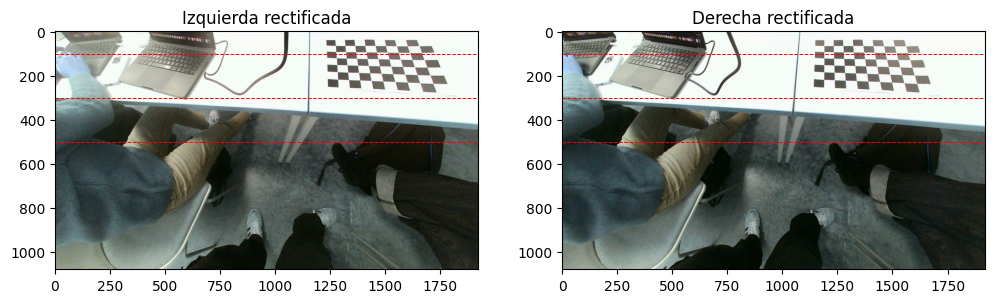

In [4]:
# Mostrar ejemplo de par de imagenes des-distorsionadas y rectificadas

# Cargar los mapas de rectificación
with open("imgs/calibracion/stereo_maps.pkl", "rb") as f:
    maps = pickle.load(f)

left_map_x, left_map_y = maps["left_map_x"], maps["left_map_y"]
right_map_x, right_map_y = maps["right_map_x"], maps["right_map_y"]

# Tomar un par de imágenes de calibración
left_img_path = sorted(glob.glob("imgs/calibracion/*left*.jpg"))[0]
right_img_path = sorted(glob.glob("imgs/calibracion/*right*.jpg"))[0]

imgL = cv2.imread(left_img_path)
imgR = cv2.imread(right_img_path)

# Aplicar rectificación
rectL = cv2.remap(imgL, left_map_x, left_map_y, cv2.INTER_LINEAR)
rectR = cv2.remap(imgR, right_map_x, right_map_y, cv2.INTER_LINEAR)

# Mostrar
fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(rectL, cmap="gray")
axes[0].set_title("Izquierda rectificada")
axes[1].imshow(rectR, cmap="gray")
axes[1].set_title("Derecha rectificada")

for y in [100, 300, 500]:
    axes[0].axhline(y, color='r', linestyle='--', linewidth=0.7)
    axes[1].axhline(y, color='r', linestyle='--', linewidth=0.7)

plt.show()

# Rectificación

In [5]:
importlib.reload(auxiliares)

auxiliares.rectificar_imagenes("imgs/objeto", "imgs/calibracion/stereo_maps.pkl")

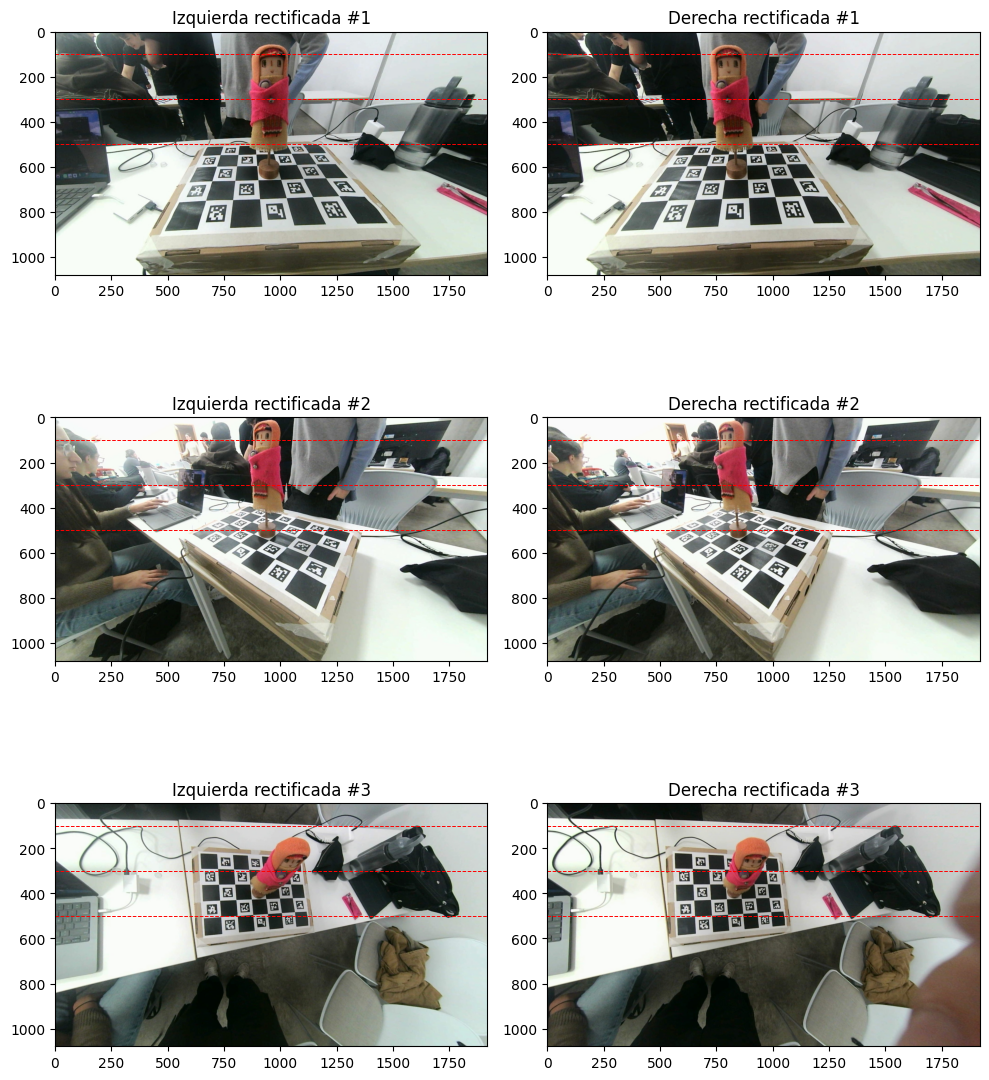

In [6]:
# Mostrar varios pares de imágenes rectificadas con líneas epipolares
left_imgs = sorted(glob.glob("imgs/objeto/rectificadas/rect_left_*.jpg"))
right_imgs = sorted(glob.glob("imgs/objeto/rectificadas/rect_right_*.jpg"))

n_ejemplos = 3  
fig, axes = plt.subplots(n_ejemplos, 2, figsize=(10, 4 * n_ejemplos))

for i in range(n_ejemplos):
    imgL = cv2.imread(left_imgs[i])
    imgR = cv2.imread(right_imgs[i])
    imgL = cv2.cvtColor(imgL, cv2.COLOR_BGR2RGB)  
    imgR = cv2.cvtColor(imgR, cv2.COLOR_BGR2RGB)

    axes[i, 0].imshow(imgL)
    axes[i, 0].set_title(f"Izquierda rectificada #{i+1}")
    axes[i, 1].imshow(imgR)
    axes[i, 1].set_title(f"Derecha rectificada #{i+1}")

    for y in [100, 300, 500]:
        axes[i, 0].axhline(y, color='r', linestyle='--', linewidth=0.7)
        axes[i, 1].axhline(y, color='r', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()


# Disparidad

### Mapa de Disparidad



In [7]:
# Seleccionar los mismos tres pares de imágenes rectificadas
pares_indices = [0, 1, 2]  
pares_imgs = [(left_imgs[i], right_imgs[i]) for i in pares_indices]

print("Pares seleccionados:")
for idx, (l, r) in zip(pares_indices, pares_imgs):
    print(f"  Par {idx+1}:")
    print(f"    Left → {os.path.basename(l)}")
    print(f"    Right → {os.path.basename(r)}")


Pares seleccionados:
  Par 1:
    Left → rect_left_0.jpg
    Right → rect_right_0.jpg
  Par 2:
    Left → rect_left_1.jpg
    Right → rect_right_1.jpg
  Par 3:
    Left → rect_left_10.jpg
    Right → rect_right_10.jpg


### Stereodemo

In [15]:
importlib.reload(auxiliares)

models_path = Path.home() / ".cache" / "stereodemo" / "models"

models_dir = Path.home() / ".cache" / "stereodemo" / "models"
models_dir.mkdir(parents=True, exist_ok=True)

auxiliares.procesar_imagenes_rectificadas(
    path_imgs="imgs/objeto/rectificadas",
    out_dir="imgs/objeto",
    metodo="cre"           
)

Encontradas 21 imágenes izquierdas
Encontradas 21 imágenes derechas



/Users/mariagonzalezdelsolar/Documents/UdeSA/2025/2 semestre/Vision/TP2_vision_artificial/venv/lib/python3.11/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


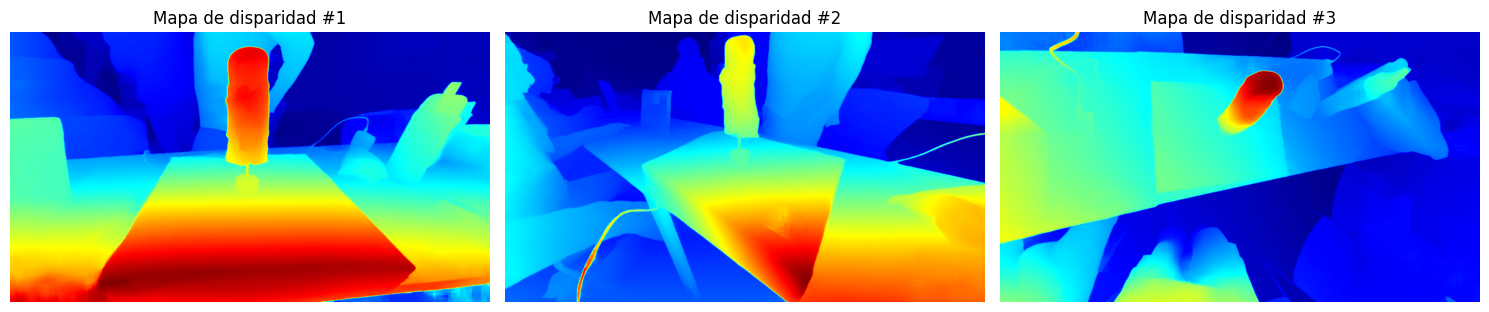

In [16]:
# Carpeta con las imágenes visuales
path_visual = "imgs/objeto/disparidad_cre"  # o "imgs/objeto/disparidad/visual"

disp_imgs = sorted(glob.glob(os.path.join(path_visual, "disp_color_*.png")))

n = 3
fig, axes = plt.subplots(1, n, figsize=(15, 5))
for i in range(n):
    disp = cv2.imread(disp_imgs[i])
    disp_rgb = cv2.cvtColor(disp, cv2.COLOR_BGR2RGB)
    axes[i].imshow(disp_rgb)
    axes[i].set_title(f"Mapa de disparidad #{i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


# Profundidad y transformacion de puntos 3D

In [20]:
importlib.reload(utils_muñeca)

point_cloud_final = utils_muñeca.reconstruccion_3d_muneca(
    max_distance_mm=1400.0,
    voxel_size_mm=1.0,
    outlier_nb_neighbors=35,
    outlier_std_ratio=0.7
)

Reconstrucción 3D
Parámetros: distancia máxima=1.4m, voxel=1.0mm
Outliers: vecinos=35, desviación=0.7

[ 1/21] left_0.jpg   15m -> 742,595 puntos
[ 2/21] left_1.jpg   13m -> 817,261 puntos
[ 3/21] left_10.jpg   13m -> 854,597 puntos
[ 4/21] left_11.jpg   12m -> 1,046,933 puntos
[ 5/21] left_12.jpg   13m -> 878,790 puntos
[ 6/21] left_13.jpg   15m -> 739,405 puntos
[ 7/21] left_14.jpg   16m -> 578,943 puntos
[ 8/21] left_15.jpg   12m -> 647,690 puntos
[ 9/21] left_16.jpg   11m -> 458,516 puntos
[10/21] left_17.jpg   11m -> 625,754 puntos
[11/21] left_18.jpg   14m -> 723,834 puntos
[12/21] left_19.jpg   13m -> 730,162 puntos
[13/21] left_2.jpg   15m -> 530,820 puntos
[14/21] left_20.jpg   14m -> 773,179 puntos
[15/21] left_3.jpg   12m -> 584,465 puntos
[16/21] left_4.jpg   13m -> 576,540 puntos
[17/21] left_5.jpg   11m -> 694,846 puntos
[18/21] left_6.jpg   10m -> 616,956 puntos
[19/21] left_7.jpg   5m -> 603,149 puntos
[20/21] left_8.jpg   13m -> 559,155 puntos
[21/21] left_9.jpg   12m 

In [18]:
if point_cloud_final is not None and len(point_cloud_final.points) > 0:
    points = np.asarray(point_cloud_final.points)
    print(f"\nTotal de puntos reconstruidos: {len(points):,}")
    
    output_completo = "imgs/objeto/reconstruccion_3d/01_nube_completa.ply"
    os.makedirs(os.path.dirname(output_completo), exist_ok=True)
    o3d.io.write_point_cloud(output_completo, point_cloud_final, write_ascii=False)
    print(f"\nArchivo 1 - Nube completa guardada: {os.path.basename(output_completo)}")
    print(f"Puntos incluidos: {len(points):,}")
    
    center_of_mass = points.mean(axis=0)

    # Búsqueda del mejor centro para el recorte
    best_density = 0
    best_center = None
    
    x_range = np.linspace(center_of_mass[0] - 200, center_of_mass[0] + 200, 5)
    y_range = np.linspace(center_of_mass[1] - 200, center_of_mass[1] + 200, 5)
    z_range = np.linspace(center_of_mass[2] - 100, center_of_mass[2] + 300, 5)
    
    for cx_test in x_range:
        for cy_test in y_range:
            for cz_test in z_range:
                extent_test = [150.0, 150.0, 150.0]
                
                mask = (np.abs(points[:, 0] - cx_test) < extent_test[0]) & \
                       (np.abs(points[:, 1] - cy_test) < extent_test[1]) & \
                       (np.abs(points[:, 2] - cz_test) < extent_test[2])
                
                count = mask.sum()
                volume = (2 * extent_test[0]) * (2 * extent_test[1]) * (2 * extent_test[2])
                density = count / volume if volume > 0 else 0
                
                if density > best_density:
                    best_density = density
                    best_center = [cx_test, cy_test, cz_test]
    
    if best_center is not None:
        print(f"Centro encontrado: [{best_center[0]:.1f}, {best_center[1]:.1f}, {best_center[2]:.1f}] mm")
        
        centro_magenta = np.array(best_center)
        
        # Configuración del primer recorte
        extent_x = 200.0
        extent_y = 200.0
        extent_z = 325.0
        
        extent_magenta = [extent_x, extent_y, extent_z]
        
        # Ajustes 
        centro_magenta[0] += 30.0
        centro_magenta[1] -= 90.0
        centro_magenta[2] -= extent_z / 2 - 40.0

        print(f"\nPrimer recorte:")
        print(f"Centro ajustado: [{centro_magenta[0]:.1f}, {centro_magenta[1]:.1f}, {centro_magenta[2]:.1f}] mm")
        print(f"Dimensiones: {extent_magenta[0]*2:.0f} x {extent_magenta[1]*2:.0f} x {extent_magenta[2]*2:.0f} mm")
        
        bbox_magenta = o3d.geometry.OrientedBoundingBox(centro_magenta, np.eye(3), extent_magenta)
        bbox_magenta.color = [1.0, 0.0, 1.0]
        
        mask_magenta = (np.abs(points[:, 0] - centro_magenta[0]) < extent_magenta[0]) & \
                       (np.abs(points[:, 1] - centro_magenta[1]) < extent_magenta[1]) & \
                       (np.abs(points[:, 2] - centro_magenta[2]) < extent_magenta[2])
        
        idx_magenta = np.where(mask_magenta)[0]
        pts_magenta = points[idx_magenta]
        
        pc_magenta = o3d.geometry.PointCloud()
        pc_magenta.points = o3d.utility.Vector3dVector(pts_magenta)
        
        if point_cloud_final.has_colors():
            cols = np.asarray(point_cloud_final.colors)
            pc_magenta.colors = o3d.utility.Vector3dVector(cols[idx_magenta])
        
        output_magenta = "imgs/objeto/reconstruccion_3d/02_recorte_bbox_magenta.ply"
        o3d.io.write_point_cloud(output_magenta, pc_magenta, write_ascii=False)
        print(f"\nArchivo 2 - Primer recorte guardado: {os.path.basename(output_magenta)}")
        print(f"Puntos incluidos: {len(pc_magenta.points):,}")
        
        centro_muneca = centro_magenta.copy()
        
        # Configuración específica para la muñeca
        extent_muneca_x = 80.0  
        extent_muneca_y = 80.0  
        extent_muneca_z = 200.0  
        
        extent_muneca = [extent_muneca_x, extent_muneca_y, extent_muneca_z]
        
        # Ajuste del centro para enfocar en la muñeca
        centro_muneca[2] += 50.0  
        
        print(f"\nSegundo recorte (solo muñeca):")
        print(f"Centro ajustado: [{centro_muneca[0]:.1f}, {centro_muneca[1]:.1f}, {centro_muneca[2]:.1f}] mm")
        print(f"Dimensiones: {extent_muneca[0]*2:.0f} x {extent_muneca[1]*2:.0f} x {extent_muneca[2]*2:.0f} mm")
        
        bbox_muneca = o3d.geometry.OrientedBoundingBox(centro_muneca, np.eye(3), extent_muneca)
        bbox_muneca.color = [0.0, 1.0, 1.0]  
        
        mask_muneca = (np.abs(pts_magenta[:, 0] - centro_muneca[0]) < extent_muneca[0]) & \
                      (np.abs(pts_magenta[:, 1] - centro_muneca[1]) < extent_muneca[1]) & \
                      (np.abs(pts_magenta[:, 2] - centro_muneca[2]) < extent_muneca[2])
        
        idx_muneca = np.where(mask_muneca)[0]
        pts_muneca = pts_magenta[idx_muneca]
        
        pc_muneca = o3d.geometry.PointCloud()
        pc_muneca.points = o3d.utility.Vector3dVector(pts_muneca)
        
        if pc_magenta.has_colors():
            cols_magenta = np.asarray(pc_magenta.colors)
            pc_muneca.colors = o3d.utility.Vector3dVector(cols_magenta[idx_muneca])
        
        output_muneca = "imgs/objeto/reconstruccion_3d/03_solo_muneca.ply"
        o3d.io.write_point_cloud(output_muneca, pc_muneca, write_ascii=False)
        print(f"\nArchivo 3 - Solo muñeca guardado: {os.path.basename(output_muneca)}")
        print(f"Puntos incluidos: {len(pc_muneca.points):,}")
        
        print("RESUMEN DE ARCHIVOS GENERADOS:")
        
        # Verificar archivos guardados
        v1 = o3d.io.read_point_cloud(output_completo)
        v2 = o3d.io.read_point_cloud(output_magenta)
        v3 = o3d.io.read_point_cloud(output_muneca)
        
        print(f"1. Nube completa: {len(v1.points):,} puntos (100%)")
        print(f"2. Primer recorte: {len(v2.points):,} puntos ({100*len(v2.points)/len(v1.points):.1f}%)")
        print(f"3. Solo muñeca: {len(v3.points):,} puntos ({100*len(v3.points)/len(v1.points):.1f}% del total)")
        
        # Visualización final
        coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(
            size=200.0,
            origin=[0, 0, 0]
        )
        
        o3d.visualization.draw_geometries(
            [pc_muneca, bbox_magenta, bbox_muneca, coordinate_frame],
            window_name="Resultado final - Solo muñeca",
            width=1280,
            height=720,
            point_show_normal=False
        )


Total de puntos reconstruidos: 11,453,574

Archivo 1 - Nube completa guardada: 01_nube_completa.ply
Puntos incluidos: 11,453,574
Centro encontrado: [95.7, -102.6, -53.8] mm

Primer recorte:
Centro ajustado: [125.7, -192.6, -176.3] mm
Dimensiones: 400 x 400 x 650 mm

Archivo 2 - Primer recorte guardado: 02_recorte_bbox_magenta.ply
Puntos incluidos: 3,149,947

Segundo recorte (solo muñeca):
Centro ajustado: [125.7, -192.6, -126.3] mm
Dimensiones: 160 x 160 x 400 mm

Archivo 3 - Solo muñeca guardado: 03_solo_muneca.ply
Puntos incluidos: 839,716
RESUMEN DE ARCHIVOS GENERADOS:
1. Nube completa: 11,453,574 puntos (100%)
2. Primer recorte: 3,149,947 puntos (27.5%)
3. Solo muñeca: 839,716 puntos (7.3% del total)


In [19]:
# Cálculo de dimensiones de la muñeca
if 'pc_muneca' in locals() and pc_muneca is not None and len(pc_muneca.points) > 0:
    print("CÁLCULO DE DIMENSIONES DE LA MUÑECA")
    
    puntos_muneca = np.asarray(pc_muneca.points)
    
    min_coords = puntos_muneca.min(axis=0)
    max_coords = puntos_muneca.max(axis=0)
    
    dimensiones_aabb = max_coords - min_coords
    ancho_x = dimensiones_aabb[0]
    profundidad_y = dimensiones_aabb[1]
    altura_z = dimensiones_aabb[2]
    
    print("1. DIMENSIONES BOUNDING BOX ALINEADA (AABB):")
    print(f"   Ancho (X): {ancho_x:.1f} mm")
    print(f"   Profundidad (Y): {profundidad_y:.1f} mm") 
    print(f"   Altura (Z): {altura_z:.1f} mm")
    print(f"   Volumen: {ancho_x * profundidad_y * altura_z / 1000:.1f} cm³")
    
    obb = pc_muneca.get_oriented_bounding_box()
    extent_obb = obb.extent
    
    dims_ordenadas = np.sort(extent_obb)
    dim_menor = dims_ordenadas[0]
    dim_media = dims_ordenadas[1] 
    dim_mayor = dims_ordenadas[2]
    
    print(f"\n2. DIMENSIONES BOUNDING BOX ORIENTADA (OBB):")
    print(f"   Dimensión menor: {dim_menor:.1f} mm")
    print(f"   Dimensión media: {dim_media:.1f} mm")
    print(f"   Dimensión mayor: {dim_mayor:.1f} mm")
    print(f"   Volumen OBB: {np.prod(extent_obb) / 1000:.1f} cm³")
    
    # Análisis por secciones verticales
    print(f"\n3. ANÁLISIS POR SECCIONES:")
    z_min, z_max = puntos_muneca[:, 2].min(), puntos_muneca[:, 2].max()
    
    n_secciones = 5
    alturas_seccion = np.linspace(z_min, z_max, n_secciones + 1)
    
    diametros_seccion = []
    for i in range(n_secciones):
        z_inf = alturas_seccion[i]
        z_sup = alturas_seccion[i + 1]
        
        mask_seccion = (puntos_muneca[:, 2] >= z_inf) & (puntos_muneca[:, 2] <= z_sup)
        puntos_seccion = puntos_muneca[mask_seccion]
        
        if len(puntos_seccion) > 10:
            x_range = puntos_seccion[:, 0].max() - puntos_seccion[:, 0].min()
            y_range = puntos_seccion[:, 1].max() - puntos_seccion[:, 1].min()
            diametro_aprox = np.mean([x_range, y_range])
            diametros_seccion.append(diametro_aprox)
            
            altura_seccion_mm = (z_inf + z_sup) / 2 - z_min
            print(f"   Sección {i+1} (altura {altura_seccion_mm:.0f}mm): diámetro {diametro_aprox:.1f} mm")
    
    if diametros_seccion:
        diametro_promedio = np.mean(diametros_seccion)
        print(f"   Diámetro promedio: {diametro_promedio:.1f} mm")
    
    # Estadísticas generales
    print(f"\n4. ESTADÍSTICAS:")
    centro_masa = puntos_muneca.mean(axis=0)
    print(f"   Centro de masa: [{centro_masa[0]:.1f}, {centro_masa[1]:.1f}, {centro_masa[2]:.1f}] mm")
    
    distancias_centro = np.linalg.norm(puntos_muneca - centro_masa, axis=1)
    radio_promedio = distancias_centro.mean()
    radio_max = distancias_centro.max()
    
    print(f"   Radio promedio: {radio_promedio:.1f} mm")
    print(f"   Radio máximo: {radio_max:.1f} mm")
    print(f"   Diámetro estimado: {radio_promedio * 2:.1f} mm")
    
    if diametros_seccion:
        circunferencia_aprox = np.pi * diametro_promedio
        print(f"   Circunferencia: {circunferencia_aprox:.1f} mm")
    
    # Guardar resultados
    resultados_path = "imgs/objeto/reconstruccion_3d/dimensiones_muneca.txt"
    with open(resultados_path, "w", encoding="utf-8") as f:
        f.write("DIMENSIONES DE LA MUÑECA\n")
        f.write("="*30 + "\n\n")
        f.write(f"Puntos analizados: {len(puntos_muneca):,}\n\n")
        f.write("AABB:\n")
        f.write(f"  Ancho (X): {ancho_x:.1f} mm\n")
        f.write(f"  Profundidad (Y): {profundidad_y:.1f} mm\n")
        f.write(f"  Altura (Z): {altura_z:.1f} mm\n")
        f.write(f"  Volumen: {ancho_x * profundidad_y * altura_z / 1000:.1f} cm³\n\n")
        f.write("OBB:\n")
        f.write(f"  Dimensión menor: {dim_menor:.1f} mm\n")
        f.write(f"  Dimensión media: {dim_media:.1f} mm\n")
        f.write(f"  Dimensión mayor: {dim_mayor:.1f} mm\n")
        f.write(f"  Volumen: {np.prod(extent_obb) / 1000:.1f} cm³\n\n")
        if diametros_seccion:
            f.write(f"Diámetro promedio: {diametro_promedio:.1f} mm\n")
            f.write(f"Circunferencia: {np.pi * diametro_promedio:.1f} mm\n")
    
    print(f"\nResultados guardados en: {os.path.basename(resultados_path)}")
    
    # Visualización
    aabb_vis = o3d.geometry.AxisAlignedBoundingBox(min_coords, max_coords)
    aabb_vis.color = [1.0, 0.0, 0.0]
    
    obb.color = [0.0, 1.0, 0.0]
    
    coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(
        size=50.0, origin=centro_masa
    )
    
    o3d.visualization.draw_geometries(
        [pc_muneca, aabb_vis, obb, coordinate_frame],
        window_name="Dimensiones de la muñeca - AABB (rojo) y OBB (verde)",
        width=1280,
        height=720,
        point_show_normal=False
    )

CÁLCULO DE DIMENSIONES DE LA MUÑECA
1. DIMENSIONES BOUNDING BOX ALINEADA (AABB):
   Ancho (X): 160.0 mm
   Profundidad (Y): 160.0 mm
   Altura (Z): 290.7 mm
   Volumen: 7442.0 cm³

2. DIMENSIONES BOUNDING BOX ORIENTADA (OBB):
   Dimensión menor: 177.5 mm
   Dimensión media: 177.8 mm
   Dimensión mayor: 292.1 mm
   Volumen OBB: 9216.5 cm³

3. ANÁLISIS POR SECCIONES:
   Sección 1 (altura 29mm): diámetro 99.0 mm
   Sección 2 (altura 87mm): diámetro 86.7 mm
   Sección 3 (altura 145mm): diámetro 89.1 mm
   Sección 4 (altura 203mm): diámetro 99.6 mm
   Sección 5 (altura 262mm): diámetro 160.0 mm
   Diámetro promedio: 106.9 mm

4. ESTADÍSTICAS:
   Centro de masa: [124.8, -189.7, -74.4] mm
   Radio promedio: 96.6 mm
   Radio máximo: 190.9 mm
   Diámetro estimado: 193.3 mm
   Circunferencia: 335.7 mm

Resultados guardados en: dimensiones_muneca.txt
